In [2]:
import os
import pandas as pd

# Load the validation dataset path from your config structure
from mimic_clip.config import VAL_CSV_PATH

def analyze_text_columns(csv_path):
    print(f"Analyzing text columns from: {csv_path}\n")
    
    # Read CSV without auto-filling so we can detect true NaNs/missing values
    df = pd.read_csv(csv_path)
    
    text_cols = ['text', 'impression_clean', 'findings_clean']
    
    # 1. Missing Values Analysis
    print("=== Missing Values ===")
    for col in text_cols:
        if col in df.columns:
            # Check for NaN or completely empty strings
            missing_count = df[col].isna().sum() + (df[col] == "").sum()
            missing_pct = (missing_count / len(df)) * 100
            print(f"Column '{col}': {missing_count:,} missing rows ({missing_pct:.2f}%)")
        else:
            print(f"Column '{col}' not found in DataFrame.")
            
    # 2. Advanced Statistics (Word counts and Redundancy)
    print("\n=== Additional Text Statistics ===")
    for col in text_cols:
        if col in df.columns:
            # Ensure text is treated as string and fill missing values for calculation
            text_series = df[col].fillna("").astype(str)
            
            # Filter out completely empty rows for the length statistics
            non_empty_series = text_series[text_series != ""]
            
            word_counts = non_empty_series.apply(lambda x: len(x.split()))
            char_counts = non_empty_series.apply(len)
            
            # Uniqueness / Redundancy (Crucial for your Soft-CLIP motivation!)
            unique_count = non_empty_series.nunique()
            total_count = len(non_empty_series)
            redundancy_pct = (1 - (unique_count / total_count)) * 100 if total_count > 0 else 0
            
            # CLIP Token Truncation Analysis (CLIP default max_length is 77 tokens)
            # Using word count as a rough proxy for token count
            exceeds_clip_limit = (word_counts > 77).sum()
            exceeds_clip_pct = (exceeds_clip_limit / total_count) * 100 if total_count > 0 else 0
            
            print(f"\n--- Column: {col} ---")
            print(f"  Total non-empty rows : {total_count:,}")
            print(f"  Unique reports       : {unique_count:,} ({100 - redundancy_pct:.2f}% unique)")
            print(f"  Clinical Redundancy  : {redundancy_pct:.2f}% of reports are duplicates")
            print(f"  Word Count - Mean    : {word_counts.mean():.1f} (Median: {word_counts.median():.0f})")
            print(f"  Word Count - Max     : {word_counts.max():.0f} (Min: {word_counts.min():.0f})")
            print(f"  Exceeds CLIP limit (>77 words): {exceeds_clip_limit:,} rows ({exceeds_clip_pct:.2f}%)")

if __name__ == "__main__":
    analyze_text_columns(VAL_CSV_PATH)

/home/omertole/.conda/envs/aimd/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyzing text columns from: /groups/orentsur_group/work/omertole/mimic_data/mimic_cxr_processed_validate.csv

=== Missing Values ===
Column 'text': 0 missing rows (0.00%)
Column 'impression_clean': 302 missing rows (10.55%)
Column 'findings_clean': 756 missing rows (26.42%)

=== Additional Text Statistics ===

--- Column: text ---
  Total non-empty rows : 2,862
  Unique reports       : 1,680 (58.70% unique)
  Clinical Redundancy  : 41.30% of reports are duplicates
  Word Count - Mean    : 59.4 (Median: 53)
  Word Count - Max     : 427 (Min: 4)
  Exceeds CLIP limit (>77 words): 615 rows (21.49%)

--- Column: impression_clean ---
  Total non-empty rows : 2,560
  Unique reports       : 1,216 (47.50% unique)
  Clinical Redundancy  : 52.50% of reports are duplicates
  Word Count - Mean    : 25.0 (Median: 15)
  Word Count - Max     : 425 (Min: 1)
  Exceeds CLIP limit (>77 words): 116 rows (4.53%)

--- Column: findings_clean ---
  Total non-empty rows : 2,106
  Unique reports       : 1,162 (

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20146.18it/s]


CLIP model loaded from checkpoints/soft/soft_findings_clean_biomedvlp_findings_clean_a0.5_t0.1 on device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 7840.56it/s]


CLIP model loaded from checkpoints/soft/soft_impression_clean_biomedvlp_impression_clean_a0.5_t0.1 on device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 7807.96it/s]


CLIP model loaded from checkpoints/soft/soft_text_biomedvlp_text_a0.5_t0.1 on device: cuda


Extracting text: 100%|██████████| 23/23 [00:06<00:00,  3.60it/s]



COMPARATIVE ERROR ANALYSIS REPORT
Total Validation Samples Evaluated: 2862
- Samples where both Findings AND Impression succeeded (R@1): 7
- Samples where Findings succeeded BUT Impression failed: 87
- Samples where Impression succeeded BUT Findings failed: 59
- Samples where Full Text succeeded BUT BOTH sub-sections failed: 108
- Semantic overlap (Jaccard Index) between sub-sections: 0.0458

QUALITATIVE EVALUATION: SAMPLE CASE STUDIES

>>> Category: Findings Succeeded, Impression Failed (Showing 5 examples) <<<

[Sample Index: 14 | Subject ID: 10057482 | Study ID: 52168780]
 - Relative Image Path: files/p10/p10057482/s52168780/5799175e-c125dfdb-3bd28e88-4f9ad41b-37bdd2ed.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10057482/s52168780/5799175e-c125dfdb-3bd28e88-4f9ad41b-37bdd2ed.jpg
 - Findings Section   : No previous images.  There are relatively low lung volumes which may accentuate the prominent transverse diameter 

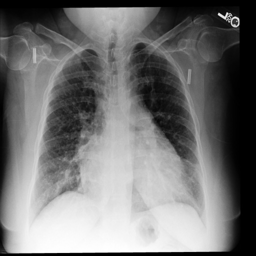

--------------------------------------------------

[Sample Index: 45 | Subject ID: 10198310 | Study ID: 57420501]
 - Relative Image Path: files/p10/p10198310/s57420501/691d5bdf-502c05bd-000c22a0-9be0768d-e13bb54d.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10198310/s57420501/691d5bdf-502c05bd-000c22a0-9be0768d-e13bb54d.jpg
 - Findings Section   : PA and lateral views of the chest provided.   Left chest wall AICD is again seen with leads extending into the right atrium and right ventricle.  The heart is moderately enlarged.  Hila appearing or urged.  There is no overt pulmonary edema.  No large effusion or pneumothorax.  No focal consolidation concerning for pneumonia.  The mediastinal contour is stable.  Bony structures are intact.  No free air below the right hemidiaphragm seen.
 - Impression Section : Moderate cardiomegaly with pulmonary vascular congestion.
 - Full Raw Report    : Findings: PA and lateral views of 

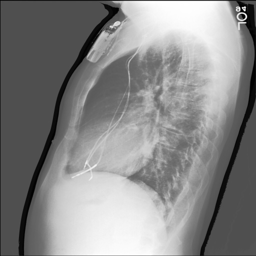

--------------------------------------------------

[Sample Index: 46 | Subject ID: 10198310 | Study ID: 57420501]
 - Relative Image Path: files/p10/p10198310/s57420501/a94f823a-d1f6f5aa-de10d9b8-37f6c6c1-e9631495.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10198310/s57420501/a94f823a-d1f6f5aa-de10d9b8-37f6c6c1-e9631495.jpg
 - Findings Section   : PA and lateral views of the chest provided.   Left chest wall AICD is again seen with leads extending into the right atrium and right ventricle.  The heart is moderately enlarged.  Hila appearing or urged.  There is no overt pulmonary edema.  No large effusion or pneumothorax.  No focal consolidation concerning for pneumonia.  The mediastinal contour is stable.  Bony structures are intact.  No free air below the right hemidiaphragm seen.
 - Impression Section : Moderate cardiomegaly with pulmonary vascular congestion.
 - Full Raw Report    : Findings: PA and lateral views of 

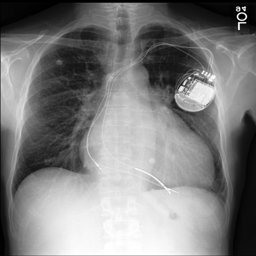

--------------------------------------------------

>>> Category: Impression Succeeded, Findings Failed (Showing 5 examples) <<<

[Sample Index: 3 | Subject ID: 10003502 | Study ID: 52139270]
 - Relative Image Path: files/p10/p10003502/s52139270/489faba7-a9dc5f1d-fd7241d6-9638d855-eaa952b1.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10003502/s52139270/489faba7-a9dc5f1d-fd7241d6-9638d855-eaa952b1.jpg
 - Findings Section   : There are moderate bilateral pleural effusions with overlying atelectasis, underlying consolidation not excluded.  Mild prominence of the interstitial markings suggests mild pulmonary edema.  The cardiac silhouette is mildly enlarged.  The mediastinal contours are unremarkable.  There is no evidence of pneumothorax.
 - Impression Section : Bilateral pleural effusions, cardiomegaly and mild edema suggest fluid overload, however, given the clinical history, underlying consolidation due to pneumonia can

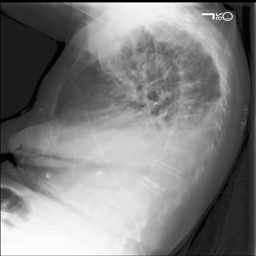

--------------------------------------------------

[Sample Index: 11 | Subject ID: 10003502 | Study ID: 57812613]
 - Relative Image Path: files/p10/p10003502/s57812613/1efa55e3-0a3856d9-421024b8-408fa7e5-81d83c1e.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10003502/s57812613/1efa55e3-0a3856d9-421024b8-408fa7e5-81d83c1e.jpg
 - Findings Section   : There is a moderate-sized left pleural effusion which is increased in size from the prior exam in ___.  There is no right pleural effusion.  The lungs are clear without pulmonary edema, consolidation, or pneumothorax.  A small calcified granuloma in the right mid-to-lower lung zone is unchanged from prior exams.  The cardiac size is mildly enlarged, unchanged from prior exams.  Mediastinal contours are normal.  The aorta is tortuous with mild calcifications.  Degenerative changes of the lower thoracic and upper lumbar spine are unchanged.
 - Impression Section : 1.  Enlarging

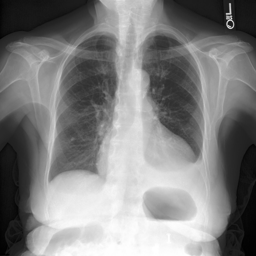

--------------------------------------------------

[Sample Index: 57 | Subject ID: 10248673 | Study ID: 55182796]
 - Relative Image Path: files/p10/p10248673/s55182796/5af7f675-13339075-9c8b61d4-bf098f85-30636763.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10248673/s55182796/5af7f675-13339075-9c8b61d4-bf098f85-30636763.jpg
 - Findings Section   : 
 - Impression Section : 1.  Interval extubation.  Right internal jugular central line and left basilar chest tube remain in place.  Lung volumes are lower on the current examination.  There is patchy opacity at the left base with an associated effusion, likely reflecting compressive atelectasis.  No evidence of pulmonary edema.  Cardiac and mediastinal contours are difficult to assess due to the low lung volumes and patient rotation on the current study, although the mediastinal contours are likely unchanged.  Status post median sternotomy for CABG.  No pneumothorax.
 - Full

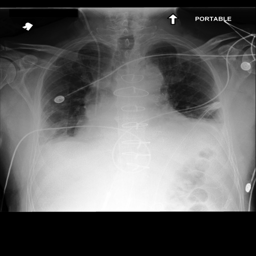

--------------------------------------------------

[Sample Index: 148 | Subject ID: 10543994 | Study ID: 58967663]
 - Relative Image Path: files/p10/p10543994/s58967663/e666163a-857953ec-9b3034d3-6020c1aa-12c0c11a.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10543994/s58967663/e666163a-857953ec-9b3034d3-6020c1aa-12c0c11a.jpg
 - Findings Section   : 
 - Impression Section : The abdomen CT showed mild pulmonary fibrosis and severe aortic valvular calcification undoubtedly stenotic.  Interstitial abnormality has predominated in the right lung. This is probably asymmetric edema.  It has improved today since ___.  Cardiomegaly is severe.  Pleural effusions are small if any.  No pneumothorax.   Right jugular infusion catheter ends low in the right atrium.  Transvenous right ventricular pacer lead in standard placement.  No pneumothorax.
 - Full Raw Report    : Findings:  Impression: The abdomen CT showed mild pulmonary fibro

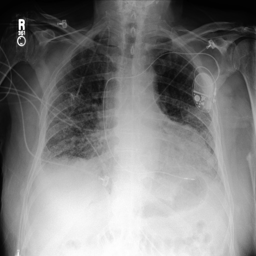

--------------------------------------------------

[Sample Index: 208 | Subject ID: 10773739 | Study ID: 53225875]
 - Relative Image Path: files/p10/p10773739/s53225875/05aa533c-2feb184d-ecec6546-ea655419-8dfdb025.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10773739/s53225875/05aa533c-2feb184d-ecec6546-ea655419-8dfdb025.jpg
 - Findings Section   : The tiny volume of residual air in the left pleural space laterally and anteriorly, in the small, stable volume of loculated left pleural fluid or pleural thickening, reflects recent removal of the left thoracostomy tube.  The left hemidiaphragm is more elevated now than it was several days ago, an indication of greater volume loss in the left lower lobe.  The right lung and pleural space and visible mediastinal contours and structures are normal.
 - Impression Section : 1. Small amount of thoracostomy related air and residual pleural fluid loculation, unchanged. 2. Mild vol

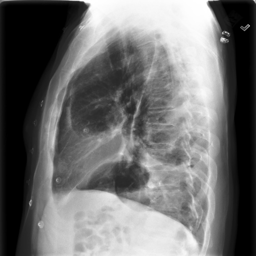

--------------------------------------------------

>>> Category: Full Text Exclusively Succeeded Where Segments Failed (Showing 5 examples) <<<

[Sample Index: 51 | Subject ID: 10199765 | Study ID: 56226668]
 - Relative Image Path: files/p10/p10199765/s56226668/53875428-43e38b4f-4474877c-8f58e8c1-9a189004.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10199765/s56226668/53875428-43e38b4f-4474877c-8f58e8c1-9a189004.jpg
 - Findings Section   : 
 - Impression Section : No relevant change as compared to the previous image.  Moderate cardiomegaly. Mild central enlargement of the pulmonary arteries. No pleural effusions. No parenchymal opacities. No pneumothorax.
 - Full Raw Report    : Findings:  Impression: No relevant change as compared to the previous image.  Moderate cardiomegaly. Mild central enlargement of the pulmonary arteries. No pleural effusions. No parenchymal opacities. No pneumothorax.
 -> Ranks -> Findings Mode

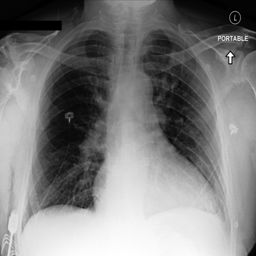

--------------------------------------------------

[Sample Index: 133 | Subject ID: 10522265 | Study ID: 58007779]
 - Relative Image Path: files/p10/p10522265/s58007779/5112f0c8-88daad36-4b8ec976-5df44b65-9b6b621b.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10522265/s58007779/5112f0c8-88daad36-4b8ec976-5df44b65-9b6b621b.jpg
 - Findings Section   : 
 - Impression Section : There are low lung volumes.  Bibasilar opacities have increased more so in the left side likely due to increasing atelectasis and a small left effusion.  The upper lungs are clear.  There is no pneumothorax.  Cardiomegaly is stable.  Left PICC tip is in the lower SVC
 - Full Raw Report    : Findings:  Impression: There are low lung volumes.  Bibasilar opacities have increased more so in the left side likely due to increasing atelectasis and a small left effusion.  The upper lungs are clear.  There is no pneumothorax.  Cardiomegaly is stable.  Left PI

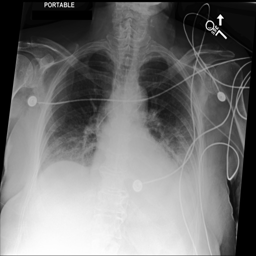

--------------------------------------------------

[Sample Index: 150 | Subject ID: 10543994 | Study ID: 59627293]
 - Relative Image Path: files/p10/p10543994/s59627293/ef13f435-fe872e16-39f17cfe-50700e9c-c69a04d3.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10543994/s59627293/ef13f435-fe872e16-39f17cfe-50700e9c-c69a04d3.jpg
 - Findings Section   : 
 - Impression Section : Mild interstitial edema has minimally worsened. There are low lung volumes. Patient has underline interstitial lung disease / fibrosis. There is no pneumothorax. Cardiomegaly and widened mediastinum are stable. Right port catheter tip is in the upper right atrium. Pacemaker lead tip is in the right ventricle.
 - Full Raw Report    : Findings:  Impression: Mild interstitial edema has minimally worsened. There are low lung volumes. Patient has underline interstitial lung disease / fibrosis. There is no pneumothorax. Cardiomegaly and widened mediastinum

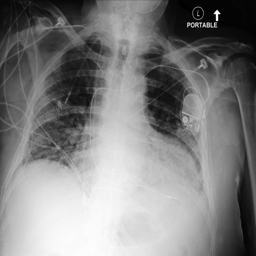

--------------------------------------------------

[Sample Index: 224 | Subject ID: 10803114 | Study ID: 52569432]
 - Relative Image Path: files/p10/p10803114/s52569432/21b088f4-785d17f9-7d448101-6744c865-87dd790b.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10803114/s52569432/21b088f4-785d17f9-7d448101-6744c865-87dd790b.jpg
 - Findings Section   : 
 - Impression Section : Pigtail right base.  No pneumothorax, reduced effusion.
 - Full Raw Report    : Findings:  Impression: Pigtail right base.  No pneumothorax, reduced effusion.
 -> Ranks -> Findings Model: 661 | Impression Model: 5 | Full Model: 1


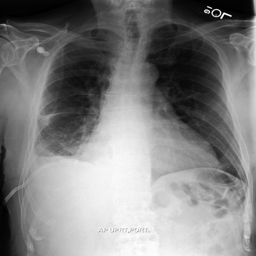

--------------------------------------------------

[Sample Index: 290 | Subject ID: 11135350 | Study ID: 53277637]
 - Relative Image Path: files/p11/p11135350/s53277637/f3a27e2d-1d0d73bc-b7394f0c-7ed82c79-189ddee5.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11135350/s53277637/f3a27e2d-1d0d73bc-b7394f0c-7ed82c79-189ddee5.jpg
 - Findings Section   : Since the chest radiographs obtained 3 days prior, there has been a significant increase in left lung atelectasis with leftward mediastinal shift. Patient positioning does not account for all apparent mediastinal shift.  Unable to assess for concomitant left pleural effusions or consolidation.  The right lung is fully expanded and clear.
 - Impression Section : Subtotal left lung collapse with significant leftward mediastinal shift concerning for an airway obstruction such as an endobronchial lesion, foreign body, or mucous plug.  NOTIFICATION:   The findings were discussed 

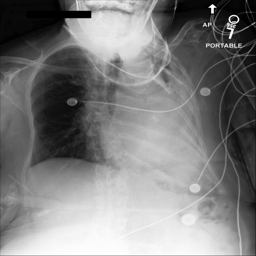

--------------------------------------------------


In [3]:
import os
import re
import numpy as np
import pandas as pd
import torch
import tqdm
from mimic_clip import ExperimentConfig, build_dataloaders, load_clip, clip_features, get_study_id
from mimic_clip.config import IMAGE_DIR 
from PIL import Image 


def extract_sample_ranks(checkpoint_path, config_args):
    """
    Loads a checkpoint and computes the absolute rank of the true match 
    for every single query sample in the validation set.
    """
    config = ExperimentConfig(
        loss_type=config_args["loss_type"],
        text_field=config_args["text_field"],
        embeddings_tag=config_args.get("embeddings_tag"),
        batch_size=128,
        num_workers=4
    ).finalize()
    
    _, val_loader, df_val = build_dataloaders(config, mode="eval")
    model, processor, device = load_clip(checkpoint=checkpoint_path)
    model.eval()
    
    all_image_features = []
    all_text_features = []
    
    # 1. Extract unified features across the validation loader
    with torch.no_grad():
        for batch in tqdm.tqdm(val_loader, desc=f"Extracting {config_args['text_field']}"):
            images, texts = batch[0], batch[1]
            img_feats, txt_feats = clip_features(model, processor, images, texts, device)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
            all_image_features.append(img_feats.cpu())
            all_text_features.append(txt_feats.cpu())
            
    all_image_features = torch.cat(all_image_features, dim=0)
    all_text_features = torch.cat(all_text_features, dim=0)
    
    # 2. Compute the full similarity matrix
    sim_matrix = torch.matmul(all_image_features, all_text_features.t()).numpy()
    
    df_val = df_val.copy()
    df_val["study_id"] = df_val["image"].apply(get_study_id)
    study_ids = df_val["study_id"].values
    
    # 3. Calculate rank of the correct study for each query sample (Image-to-Text)
    sample_ranks = []
    num_queries = sim_matrix.shape[0]
    for i in range(num_queries):
        query_study = study_ids[i]
        sorted_indices = np.argsort(-sim_matrix[i])
        retrieved_studies = study_ids[sorted_indices]
        
        first_match_rank = np.where(retrieved_studies == query_study)[0][0] + 1
        sample_ranks.append(first_match_rank)
        
    return np.array(sample_ranks), df_val

# =====================================================================
# 1. RUN FEATURE EXTRACTION FOR DESIRED CONFIGURATIONS
# =====================================================================

# Define your checkpoints and configurations to analyze
models_to_compare = {
    "findings": {
        "path": "checkpoints/soft/soft_findings_clean_biomedvlp_findings_clean_a0.5_t0.1",
        "config": {"loss_type": "soft", "text_field": "findings_clean", "embeddings_tag": "biomedvlp_findings_clean"}
    },
    "impression": {
        "path": "checkpoints/soft/soft_impression_clean_biomedvlp_impression_clean_a0.5_t0.1",
        "config": {"loss_type": "soft", "text_field": "impression_clean", "embeddings_tag": "biomedvlp_impression_clean"}
    },
    "full_text": {
        "path": "checkpoints/soft/soft_text_biomedvlp_text_a0.5_t0.1",
        "config": {"loss_type": "soft", "text_field": "text", "embeddings_tag": "biomedvlp_text"}
    }
}

# Dictionary to hold the raw rank vectors per model configuration
ranks_dict = {}
base_df = None

for key, meta in models_to_compare.items():
    if os.path.exists(meta["path"]):
        ranks, df_val = extract_sample_ranks(meta["path"], meta["config"])
        ranks_dict[key] = ranks
        if base_df is None:
            base_df = df_val
    else:
        print(f"Warning: Checkpoint path not found for {key}, skipping visualization setup.")

# =====================================================================
# 2. EVALUATE COMPARATIVE TRENDS AND INTERSECTIONS
# =====================================================================
if "findings" in ranks_dict and "impression" in ranks_dict and "full_text" in ranks_dict:
    # Define success criteria (Top-1 Retrieval success)
    success_find = (ranks_dict["findings"] == 1)
    success_impr = (ranks_dict["impression"] == 1)
    success_full = (ranks_dict["full_text"] == 1)
    
    total_samples = len(base_df)
    
    # Calculate Intersections
    both_sections_success = np.where(success_find & success_impr)[0]
    findings_only_success = np.where(success_find & ~success_impr)[0]
    impression_only_success = np.where(success_impr & ~success_find)[0]
    full_text_only_success = np.where(success_full & ~success_find & ~success_impr)[0]
    
    print("\n" + "="*60)
    print("COMPARATIVE ERROR ANALYSIS REPORT")
    print("="*60)
    print(f"Total Validation Samples Evaluated: {total_samples}")
    print(f"- Samples where both Findings AND Impression succeeded (R@1): {len(both_sections_success)}")
    print(f"- Samples where Findings succeeded BUT Impression failed: {len(findings_only_success)}")
    print(f"- Samples where Impression succeeded BUT Findings failed: {len(impression_only_success)}")
    print(f"- Samples where Full Text succeeded BUT BOTH sub-sections failed: {len(full_text_only_success)}")
    
    # Calculate Jaccard Overlap Index between sections
    union_count = np.sum(success_find | success_impr)
    jaccard_index = len(both_sections_success) / union_count if union_count > 0 else 0
    print(f"- Semantic overlap (Jaccard Index) between sub-sections: {jaccard_index:.4f}")
        
    # =====================================================================
    # 3. PRINT SPECIFIC SAMPLES FOR QUALITATIVE RESEARCH ANALYSIS
    # =====================================================================

    print("\n" + "="*60)
    print("QUALITATIVE EVALUATION: SAMPLE CASE STUDIES")
    print("="*60)

    def print_case_study(indices_list, category_label, max_prints=5):
        print(f"\n>>> Category: {category_label} (Showing {min(max_prints, len(indices_list))} examples) <<<")
        for idx in indices_list[:max_prints]:
            row = base_df.iloc[idx]
            
            # Extract relative path from CSV
            rel_img_path = row['image']
            
            # Apply the fix from before if your CSV path has a redundant 'file/' prefix
            # if rel_img_path.startswith("file/"):
            #     rel_img_path = rel_img_path.replace("file/", "", 1)
                
            # Compute the full absolute path on the server/cluster
            full_img_path = os.path.join(IMAGE_DIR, rel_img_path)
            
            print(f"\n[Sample Index: {idx} | Subject ID: {row['subject_id']} | Study ID: {row['study_id']}]")
            print(f" - Relative Image Path: {row['image']}")
            print(f" - Absolute Image Path: {full_img_path}")
            print(f" - Findings Section   : {row['findings_clean']}")
            print(f" - Impression Section : {row['impression_clean']}")
            print(f" - Full Raw Report    : {row['text']}")
            print(f" -> Ranks -> Findings Model: {ranks_dict['findings'][idx]} | Impression Model: {ranks_dict['impression'][idx]} | Full Model: {ranks_dict['full_text'][idx]}")
            
            # Optional: If you are running in a Jupyter Notebook and want to display the image inline:
            try:
                from IPython.display import display
                img = Image.open(full_img_path)
                # Resize just for visualization purposes in the notebook
                img.thumbnail((256, 256)) 
                display(img)
            except Exception as e:
                print(f" -> Could not display image: {e}")
                
            print("-" * 50)

    # Print relevant clinical examples for paper discussion
    print_case_study(findings_only_success, "Findings Succeeded, Impression Failed")
    print_case_study(impression_only_success, "Impression Succeeded, Findings Failed")
    print_case_study(full_text_only_success, "Full Text Exclusively Succeeded Where Segments Failed")


COMPARATIVE ERROR ANALYSIS REPORT (COMPLETE REPORTS ONLY)
Total Validation Samples with BOTH sections: 1804
- Samples where both Findings AND Impression succeeded (R@1): 7
- Samples where Findings succeeded BUT Impression failed: 71
- Samples where Impression succeeded BUT Findings failed: 28
- Samples where Full Text succeeded BUT BOTH sub-sections failed: 58
- Semantic overlap (Jaccard Index) between sub-sections: 0.0660

QUALITATIVE EVALUATION: SAMPLE CASE STUDIES

>>> Category: Findings Succeeded, Impression Failed (Showing 5 examples) <<<

[Sample Index (Filtered): 12 | Subject ID: 10075925 | Study ID: 51010496]
 - Relative Image Path: files/p10/p10075925/s51010496/2d783c8a-492984b7-28aaf571-bfc30156-61ab26f6.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10075925/s51010496/2d783c8a-492984b7-28aaf571-bfc30156-61ab26f6.jpg
 - Findings Section   : Mild pulmonary vascular congestion with mild to moderate interstitial p

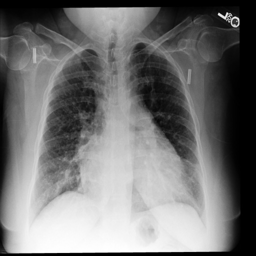

--------------------------------------------------

[Sample Index (Filtered): 23 | Subject ID: 10198310 | Study ID: 57420501]
 - Relative Image Path: files/p10/p10198310/s57420501/691d5bdf-502c05bd-000c22a0-9be0768d-e13bb54d.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10198310/s57420501/691d5bdf-502c05bd-000c22a0-9be0768d-e13bb54d.jpg
 - Findings Section   : PA and lateral views of the chest provided.   Left chest wall AICD is again seen with leads extending into the right atrium and right ventricle.  The heart is moderately enlarged.  Hila appearing or urged.  There is no overt pulmonary edema.  No large effusion or pneumothorax.  No focal consolidation concerning for pneumonia.  The mediastinal contour is stable.  Bony structures are intact.  No free air below the right hemidiaphragm seen.
 - Impression Section : Moderate cardiomegaly with pulmonary vascular congestion.
 - Full Raw Report    : Findings: PA and latera

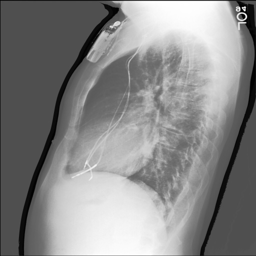

--------------------------------------------------

[Sample Index (Filtered): 24 | Subject ID: 10198310 | Study ID: 57420501]
 - Relative Image Path: files/p10/p10198310/s57420501/a94f823a-d1f6f5aa-de10d9b8-37f6c6c1-e9631495.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10198310/s57420501/a94f823a-d1f6f5aa-de10d9b8-37f6c6c1-e9631495.jpg
 - Findings Section   : PA and lateral views of the chest provided.   Left chest wall AICD is again seen with leads extending into the right atrium and right ventricle.  The heart is moderately enlarged.  Hila appearing or urged.  There is no overt pulmonary edema.  No large effusion or pneumothorax.  No focal consolidation concerning for pneumonia.  The mediastinal contour is stable.  Bony structures are intact.  No free air below the right hemidiaphragm seen.
 - Impression Section : Moderate cardiomegaly with pulmonary vascular congestion.
 - Full Raw Report    : Findings: PA and latera

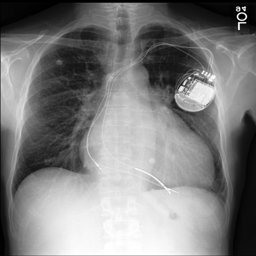

--------------------------------------------------

[Sample Index (Filtered): 49 | Subject ID: 10337896 | Study ID: 55070875]
 - Relative Image Path: files/p10/p10337896/s55070875/3eb3bf96-c5401aea-07178eee-c43e5e80-600f6a33.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10337896/s55070875/3eb3bf96-c5401aea-07178eee-c43e5e80-600f6a33.jpg
 - Findings Section   : The NG tube not well visualized, but may pass into the abdomen. Diffuse bilateral pulmonary opacifications are again seen, unchanged from prior exam. ET tube and right IJ central line are in stable position from prior exam.
 - Impression Section : NG tube not well visualized, but may pass into the abdomen.  If it is a better visualization is desired, repeat radiographs with abdominal technique can be performed.
 - Full Raw Report    : Findings: The NG tube not well visualized, but may pass into the abdomen. Diffuse bilateral pulmonary opacifications are again seen,

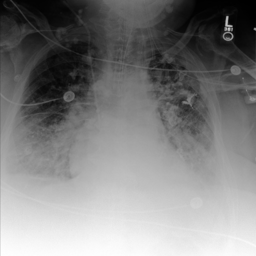

--------------------------------------------------

[Sample Index (Filtered): 50 | Subject ID: 10337896 | Study ID: 55070875]
 - Relative Image Path: files/p10/p10337896/s55070875/44bec237-520a0e5b-80e20d64-2c0a9036-c8766a81.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10337896/s55070875/44bec237-520a0e5b-80e20d64-2c0a9036-c8766a81.jpg
 - Findings Section   : The NG tube not well visualized, but may pass into the abdomen. Diffuse bilateral pulmonary opacifications are again seen, unchanged from prior exam. ET tube and right IJ central line are in stable position from prior exam.
 - Impression Section : NG tube not well visualized, but may pass into the abdomen.  If it is a better visualization is desired, repeat radiographs with abdominal technique can be performed.
 - Full Raw Report    : Findings: The NG tube not well visualized, but may pass into the abdomen. Diffuse bilateral pulmonary opacifications are again seen,

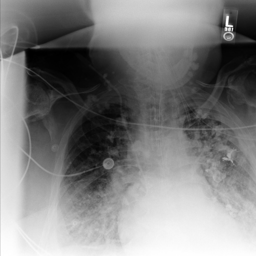

--------------------------------------------------

>>> Category: Impression Succeeded, Findings Failed (Showing 5 examples) <<<

[Sample Index (Filtered): 0 | Subject ID: 10003502 | Study ID: 52139270]
 - Relative Image Path: files/p10/p10003502/s52139270/489faba7-a9dc5f1d-fd7241d6-9638d855-eaa952b1.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10003502/s52139270/489faba7-a9dc5f1d-fd7241d6-9638d855-eaa952b1.jpg
 - Findings Section   : There are moderate bilateral pleural effusions with overlying atelectasis, underlying consolidation not excluded.  Mild prominence of the interstitial markings suggests mild pulmonary edema.  The cardiac silhouette is mildly enlarged.  The mediastinal contours are unremarkable.  There is no evidence of pneumothorax.
 - Impression Section : Bilateral pleural effusions, cardiomegaly and mild edema suggest fluid overload, however, given the clinical history, underlying consolidation due to pn

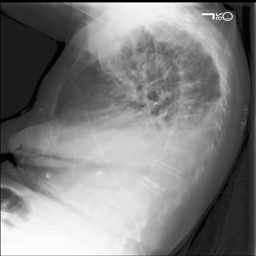

--------------------------------------------------

[Sample Index (Filtered): 8 | Subject ID: 10003502 | Study ID: 57812613]
 - Relative Image Path: files/p10/p10003502/s57812613/1efa55e3-0a3856d9-421024b8-408fa7e5-81d83c1e.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10003502/s57812613/1efa55e3-0a3856d9-421024b8-408fa7e5-81d83c1e.jpg
 - Findings Section   : There is a moderate-sized left pleural effusion which is increased in size from the prior exam in ___.  There is no right pleural effusion.  The lungs are clear without pulmonary edema, consolidation, or pneumothorax.  A small calcified granuloma in the right mid-to-lower lung zone is unchanged from prior exams.  The cardiac size is mildly enlarged, unchanged from prior exams.  Mediastinal contours are normal.  The aorta is tortuous with mild calcifications.  Degenerative changes of the lower thoracic and upper lumbar spine are unchanged.
 - Impression Section : 1. 

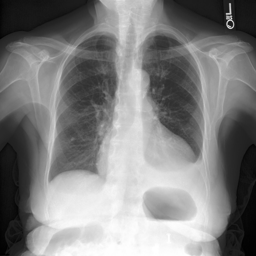

--------------------------------------------------

[Sample Index (Filtered): 117 | Subject ID: 10773739 | Study ID: 53225875]
 - Relative Image Path: files/p10/p10773739/s53225875/05aa533c-2feb184d-ecec6546-ea655419-8dfdb025.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10773739/s53225875/05aa533c-2feb184d-ecec6546-ea655419-8dfdb025.jpg
 - Findings Section   : The tiny volume of residual air in the left pleural space laterally and anteriorly, in the small, stable volume of loculated left pleural fluid or pleural thickening, reflects recent removal of the left thoracostomy tube.  The left hemidiaphragm is more elevated now than it was several days ago, an indication of greater volume loss in the left lower lobe.  The right lung and pleural space and visible mediastinal contours and structures are normal.
 - Impression Section : 1. Small amount of thoracostomy related air and residual pleural fluid loculation, unchanged. 

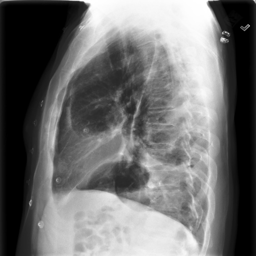

--------------------------------------------------

[Sample Index (Filtered): 121 | Subject ID: 10773739 | Study ID: 59278582]
 - Relative Image Path: files/p10/p10773739/s59278582/0634e821-c53b5925-d799ae9a-7d89063e-d8f88591.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10773739/s59278582/0634e821-c53b5925-d799ae9a-7d89063e-d8f88591.jpg
 - Findings Section   : Cardiomediastinal contours are normal. The right lung is clear. There is no pneumothorax or right pleural effusion. There is mild elevation of the left hemidiaphragm unchanged from prior. Opacities in the left lower hemithorax have markedly improved with residual probably scarring. Blunting of the left costophrenic angles could represent a small effusion or pleural thickening.  The osseous structures are unremarkable
 - Impression Section : No acute cardiopulmonary abnormalities.  Minimal residual linear opacities in the left lower lung likely scarring and small l

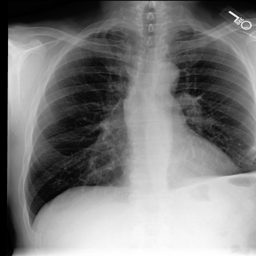

--------------------------------------------------

[Sample Index (Filtered): 126 | Subject ID: 10803114 | Study ID: 50512608]
 - Relative Image Path: files/p10/p10803114/s50512608/49910657-1f377f22-5cc20631-adab4e1a-1debb4b0.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p10/p10803114/s50512608/49910657-1f377f22-5cc20631-adab4e1a-1debb4b0.jpg
 - Findings Section   : Small right apical and basilar pneumothorax is not significantly changed compared to the most recent radiograph from ___.  The previously seen small caliber right pleural catheter on the prior chest radiograph is no longer identified.  There are two new larger bore pleural catheters projecting over the right lung base.  There has been interval improvement of the small right-sided pleural effusion.  The left lung is clear without evidence of focal consolidations. There is mild right basilar atelectasis.  The hilar and mediastinal contours are normal.
 - Impression 

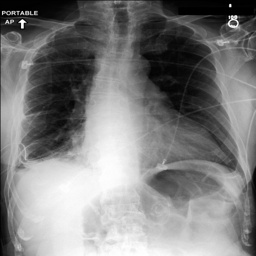

--------------------------------------------------

>>> Category: Full Text Exclusively Succeeded Where Segments Failed (Showing 5 examples) <<<

[Sample Index (Filtered): 176 | Subject ID: 11135350 | Study ID: 53277637]
 - Relative Image Path: files/p11/p11135350/s53277637/f3a27e2d-1d0d73bc-b7394f0c-7ed82c79-189ddee5.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11135350/s53277637/f3a27e2d-1d0d73bc-b7394f0c-7ed82c79-189ddee5.jpg
 - Findings Section   : Since the chest radiographs obtained 3 days prior, there has been a significant increase in left lung atelectasis with leftward mediastinal shift. Patient positioning does not account for all apparent mediastinal shift.  Unable to assess for concomitant left pleural effusions or consolidation.  The right lung is fully expanded and clear.
 - Impression Section : Subtotal left lung collapse with significant leftward mediastinal shift concerning for an airway obstruction suc

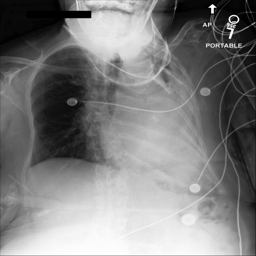

--------------------------------------------------

[Sample Index (Filtered): 188 | Subject ID: 11181748 | Study ID: 53610077]
 - Relative Image Path: files/p11/p11181748/s53610077/c75317be-225faf00-b7bccd06-b199a930-a4ef45ff.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11181748/s53610077/c75317be-225faf00-b7bccd06-b199a930-a4ef45ff.jpg
 - Findings Section   : Right-sided pleural effusion has minimally decreased.  Right-sided adjacent atelectasis and fluid along the fissure have also decreased.  The left lung is clear.  The cardiomediastinal silhouette is unchanged.  Numerous calcified lesions in the right chest wall are stable.
 - Impression Section : Slight interval decrease in right-sided pleural effusion and atelectasis.
 - Full Raw Report    : Findings: Right-sided pleural effusion has minimally decreased.  Right-sided adjacent atelectasis and fluid along the fissure have also decreased.  The left lung is clear.  T

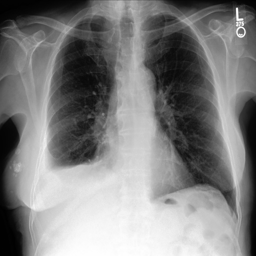

--------------------------------------------------

[Sample Index (Filtered): 192 | Subject ID: 11181748 | Study ID: 55851177]
 - Relative Image Path: files/p11/p11181748/s55851177/6fab1ad7-445ea2a4-e4074846-ffc0bcd0-3a5972ca.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11181748/s55851177/6fab1ad7-445ea2a4-e4074846-ffc0bcd0-3a5972ca.jpg
 - Findings Section   : A large right pleural effusion is new from the prior study.  Superimposed opacity likely represents compressive atelectasis, however infectious process could be considered the proper clinical setting.  There is no left pleural effusion.  There is mild pulmonary vascular congestion without overt pulmonary edema.
 - Impression Section : 1. New large right pleural effusion. 2. Superimposed opacity may represent compressive atelectasis or infectious process in the proper clinical setting. 3. Mild pulmonary vascular congestion without overt pulmonary edema.
 - Full Raw

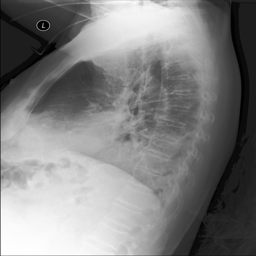

--------------------------------------------------

[Sample Index (Filtered): 198 | Subject ID: 11216230 | Study ID: 57239326]
 - Relative Image Path: files/p11/p11216230/s57239326/cb6b6702-9109f7be-cb626f90-5de5b6ef-4f4c7ad9.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11216230/s57239326/cb6b6702-9109f7be-cb626f90-5de5b6ef-4f4c7ad9.jpg
 - Findings Section   : No focal consolidation, pleural effusion or pneumothorax is seen.  Prominent bilateral interstitial markings are stable from prior exam.  The cardiac silhouette is normal in size.  Multiple bilateral rib deformities reflect prior fractures.
 - Impression Section : No acute cardiopulmonary process.
 - Full Raw Report    : Findings: No focal consolidation, pleural effusion or pneumothorax is seen.  Prominent bilateral interstitial markings are stable from prior exam.  The cardiac silhouette is normal in size.  Multiple bilateral rib deformities reflect prior fractur

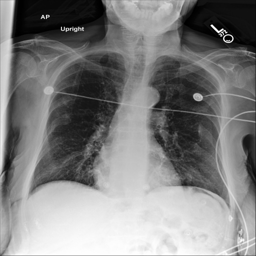

--------------------------------------------------

[Sample Index (Filtered): 214 | Subject ID: 11226572 | Study ID: 59951875]
 - Relative Image Path: files/p11/p11226572/s59951875/1231dc8f-4cf6ae66-2754d2f7-db1abf04-fe0eb62b.jpg
 - Absolute Image Path: /groups/orentsur_group/work/omertole/mimic_data/official_data_iccv_final/files/p11/p11226572/s59951875/1231dc8f-4cf6ae66-2754d2f7-db1abf04-fe0eb62b.jpg
 - Findings Section   : Frontal and lateral views of the chest were obtained.  No focal consolidation, pleural effusion, or evidence of pneumothorax is seen.  Mild left base and lingular linear atelectasis/scarring is seen.  The cardiac and mediastinal silhouettes are stable and unremarkable.
 - Impression Section : No acute cardiopulmonary process.
 - Full Raw Report    : Findings: Frontal and lateral views of the chest were obtained.  No focal consolidation, pleural effusion, or evidence of pneumothorax is seen.  Mild left base and lingular linear atelectasis/scarring is seen.  The car

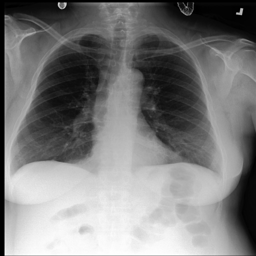

--------------------------------------------------


In [4]:
# =====================================================================
# 2. EVALUATE COMPARATIVE TRENDS AND INTERSECTIONS (FILTERED FOR COMPLETE REPORTS)
# =====================================================================
if "findings" in ranks_dict and "impression" in ranks_dict and "full_text" in ranks_dict:
    
    # Create a mask for rows that have BOTH findings and impression populated
    # (Checking against empty strings and NaN values)
    valid_mask = (
        (base_df["findings_clean"].fillna("") != "") & 
        (base_df["impression_clean"].fillna("") != "")
    ).values
    
    # Filter the ranks arrays and the base DataFrame to keep only complete records
    filtered_df = base_df[valid_mask].reset_index(drop=True)
    filtered_ranks_find = ranks_dict["findings"][valid_mask]
    filtered_ranks_impr = ranks_dict["impression"][valid_mask]
    filtered_ranks_full = ranks_dict["full_text"][valid_mask]
    
    total_samples = len(filtered_df)
    
    # Define success criteria on the filtered subsets (Top-1 Retrieval success)
    success_find = (filtered_ranks_find == 1)
    success_impr = (filtered_ranks_impr == 1)
    success_full = (filtered_ranks_full == 1)
    
    # Calculate Intersections based on the filtered data
    both_sections_success = np.where(success_find & success_impr)[0]
    findings_only_success = np.where(success_find & ~success_impr)[0]
    impression_only_success = np.where(success_impr & ~success_find)[0]
    full_text_only_success = np.where(success_full & ~success_find & ~success_impr)[0]
    
    print("\n" + "="*60)
    print("COMPARATIVE ERROR ANALYSIS REPORT (COMPLETE REPORTS ONLY)")
    print("="*60)
    print(f"Total Validation Samples with BOTH sections: {total_samples}")
    print(f"- Samples where both Findings AND Impression succeeded (R@1): {len(both_sections_success)}")
    print(f"- Samples where Findings succeeded BUT Impression failed: {len(findings_only_success)}")
    print(f"- Samples where Impression succeeded BUT Findings failed: {len(impression_only_success)}")
    print(f"- Samples where Full Text succeeded BUT BOTH sub-sections failed: {len(full_text_only_success)}")
    
    # Calculate Jaccard Overlap Index between sections on the filtered data
    union_count = np.sum(success_find | success_impr)
    jaccard_index = len(both_sections_success) / union_count if union_count > 0 else 0
    print(f"- Semantic overlap (Jaccard Index) between sub-sections: {jaccard_index:.4f}")
    
    # =====================================================================
    # 3. PRINT SPECIFIC SAMPLES FOR QUALITATIVE RESEARCH ANALYSIS
    # =====================================================================
    from mimic_clip.config import IMAGE_DIR
    
    print("\n" + "="*60)
    print("QUALITATIVE EVALUATION: SAMPLE CASE STUDIES")
    print("="*60)
    
    def print_case_study(indices_list, category_label, max_prints=5):
        print(f"\n>>> Category: {category_label} (Showing {min(max_prints, len(indices_list))} examples) <<<")
        for idx in indices_list[:max_prints]:
            row = filtered_df.iloc[idx]
            
            # Compute absolute image paths based on the filtered rows
            rel_img_path = row['image']
            
            # Optional fix: uncomment if your CSV paths contain a redundant 'file/' prefix
            # if rel_img_path.startswith("file/"):
            #     rel_img_path = rel_img_path.replace("file/", "", 1)
                
            full_img_path = os.path.join(IMAGE_DIR, rel_img_path)
            
            print(f"\n[Sample Index (Filtered): {idx} | Subject ID: {row['subject_id']} | Study ID: {row['study_id']}]")
            print(f" - Relative Image Path: {row['image']}")
            print(f" - Absolute Image Path: {full_img_path}")
            print(f" - Findings Section   : {row['findings_clean']}")
            print(f" - Impression Section : {row['impression_clean']}")
            print(f" - Full Raw Report    : {row['text']}")
            print(f" -> Ranks -> Findings Model: {filtered_ranks_find[idx]} | Impression Model: {filtered_ranks_impr[idx]} | Full Model: {filtered_ranks_full[idx]}")
            
            # Optional: If you are running in Jupyter and want to display the image inline, uncomment below:
            try:
                from IPython.display import display
                from PIL import Image
                img = Image.open(full_img_path)
                img.thumbnail((256, 256))
                display(img)
            except Exception as e:
                print(f" -> Could not display image: {e}")
                
            print("-" * 50)

    # Print relevant clinical examples from the complete reports subset
    print_case_study(findings_only_success, "Findings Succeeded, Impression Failed")
    print_case_study(impression_only_success, "Impression Succeeded, Findings Failed")
    print_case_study(full_text_only_success, "Full Text Exclusively Succeeded Where Segments Failed")
else:
    print("Error: Missing extracted ranks from one or more models in ranks_dict.")

In [6]:
import numpy as np
from scipy.stats import chi2_contingency

ranks_analysis_1 = ranks_dict 

valid_mask = (
    (base_df["findings_clean"].fillna("") != "") & 
    (base_df["impression_clean"].fillna("") != "")
).values

ranks_analysis_2 = {
    "findings": ranks_dict["findings"][valid_mask],
    "impression": ranks_dict["impression"][valid_mask],
    "full_text": ranks_dict["full_text"][valid_mask]
}


def chi_square_test(ranks_analysis_1, ranks_analysis_2):
    """
    Dynamically builds the contingency table from rank arrays and executes 
    the Chi-Square Test for Independence.
    
    Args:
        ranks_analysis_1 (dict): Dictionary of rank arrays for Analysis 1 (with missing profiles)
                                 e.g., {"findings": arr, "impression": arr, "full_text": arr}
        ranks_analysis_2 (dict): Dictionary of rank arrays for Analysis 2 (strictly non-empty profiles)
    """
    
    def calculate_counts(ranks_dict):
        # Determine Top-1 retrieval success per configuration
        success_find = (ranks_dict["findings"] == 1)
        success_impr = (ranks_dict["impression"] == 1)
        success_full = (ranks_dict["full_text"] == 1)
        
        # Calculate mutually exclusive categories for the contingency rows
        both_succeeded = np.sum(success_find & success_impr)
        findings_only  = np.sum(success_find & ~success_impr)
        impression_only = np.sum(success_impr & ~success_find)
        full_text_only = np.sum(success_full & ~success_find & ~success_impr)
        
        return [both_succeeded, findings_only, impression_only, full_text_only]

    # Dynamically extract the metric counts for both states
    row_analysis_1 = calculate_counts(ranks_analysis_1)
    row_analysis_2 = calculate_counts(ranks_analysis_2)
    
    # Construct the final contingency matrix
    contingency_table = np.array([row_analysis_1, row_analysis_2])
    
    # Execute the statistical independence test
    chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)
    
    # Print the analytical report
    print("=" * 60)
    print("DYNAMIC CHI-SQUARE TEST FOR INDEPENDENCE REPORT")
    print("=" * 60)
    print(f"Constructed Matrix:\n{contingency_table}")
    print("-" * 40)
    print(f"Chi-Square Statistic : {chi2_stat:.4f}")
    print(f"p-value              : {p_value:.4f}")
    print(f"Degrees of Freedom   : {dof}")
    print("\nExpected Frequencies Matrix:")
    print(expected_frequencies)
    print("-" * 40)
    
    if p_value < 0.05:
        print("Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
        print("The exclusion of empty text profiles fundamentally altered the underlying")
        print("distribution of model failure/success modes.")
    else:
        print("Result: NOT STATISTICALLY SIGNIFICANT (p >= 0.05)")
        print("The relative distribution of model behavior remains stable despite filtering.")
    print("=" * 60)

chi_square_test(ranks_analysis_1, ranks_analysis_2)

DYNAMIC CHI-SQUARE TEST FOR INDEPENDENCE REPORT
Constructed Matrix:
[[  7  87  59 108]
 [  7  71  28  58]]
----------------------------------------
Chi-Square Statistic : 5.8947
p-value              : 0.1168
Degrees of Freedom   : 3

Expected Frequencies Matrix:
[[  8.59764706  97.03058824  53.42823529 101.94352941]
 [  5.40235294  60.96941176  33.57176471  64.05647059]]
----------------------------------------
Result: NOT STATISTICALLY SIGNIFICANT (p >= 0.05)
The relative distribution of model behavior remains stable despite filtering.
